# EnKF vs MPDOK — Phase 4: Full Kernel Analysis

## The MPDOK Approach

Instead of estimating $\mathbf{P}_b$ from a small ensemble, MPDOK specifies it directly as a **parametric kernel matrix**:

$$[\mathbf{P}_b]_{ij} = \sigma^2 \cdot k(\mathbf{x}_i, \mathbf{x}_j)$$

where $k$ is the **Matérn-3/2** kernel — the standard choice for physical fields with continuous but not smooth derivatives (exactly the roughness class of atmospheric turbulence):

$$k_{\text{Matérn-3/2}}(d) = \left(1 + \frac{\sqrt{3}\, d}{L}\right) \exp\!\left(-\frac{\sqrt{3}\, d}{L}\right)$$

The length scale $L$ was fitted to the true empirical correlation in Phase 2: **L = 1069 km**.

> **Statistical framing:** MPDOK treats data assimilation as a **Kernel Ridge Regression (KRR)** problem. Rather than solving the raw dynamical equations of motion, it operates on the Gram matrix of spatial similarities defined by the Matérn kernel. The Kalman update is the KRR solution in the function space induced by that kernel — which is exactly the RKHS of functions with continuous but non-smooth first derivatives, matching the known regularity class of atmospheric turbulence.

### What changes vs EnKF

| | EnKF | MPDOK |
|--|--|--|
| Covariance source | k=50 ensemble samples | Matérn-3/2 kernel (fitted) |
| Matrix rank | 49 | **N = 578 (full rank)** |
| Localization | Gaspari-Cohn, R=1000 km | None — kernel decays naturally |
| Obs using SQ321 region | 2 of 30 | **30 of 30** |
| Covariance quality | Sampling noise + truncation | Parametric, no sampling error |

Everything else is identical: same background, same observations, same Kalman update formula.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── load all upstream data ────────────────────────────────────────────────────
d1 = np.load('phase1_data.npz')
d2 = np.load('phase2_data.npz')
d3 = np.load('phase3_enkf.npz')

lat        = d1['lat'];          lon        = d1['lon']
u250       = d1['u250'];         v250       = d1['v250']
TI_truth   = d1['TI_truth_scaled']
coords_lat = d1['coords_lat'];   coords_lon = d1['coords_lon']
SQ321_LAT  = float(d1['sq321_lat'])
SQ321_LON  = float(d1['sq321_lon'])
sq_ilat    = int(d1['sq_ilat']); sq_ilon    = int(d1['sq_ilon'])

x_truth      = d2['x_truth']
x_background = d2['x_background']
y_obs        = d2['y_obs']
H            = d2['H']
R_obs        = d2['R_obs']
obs_idx      = d2['obs_idx']
obs_lat      = d2['obs_lat'];    obs_lon    = d2['obs_lon']
D            = d2['D']
sigma_obs    = float(d2['sigma_obs'])
sigma_bg     = float(d2['sigma_bg'])
R_loc        = float(d2['R_loc'])
L_matern     = float(d2['L_matern'])
sq_grid_idx  = int(d2['sq_grid_idx'])

x_enkf           = d3['x_enkf']
rmse_bg          = float(d3['rmse_bg'])
rmse_enkf        = float(d3['rmse_enkf'])
err_bg_sq        = float(d3['err_bg_sq'])
err_enkf_sq      = float(d3['err_enkf_sq'])
err_bg_ti        = float(d3['err_bg_ti'])
err_enkf_ti      = float(d3['err_enkf_ti'])
gain_sq321_enkf  = float(d3['gain_sq321_enkf'])
nearest_obs_k    = int(d3['nearest_obs_k'])
nearest_obs_lat  = float(d3['nearest_obs_lat'])
nearest_obs_lon  = float(d3['nearest_obs_lon'])
nearest_obs_dist = float(d3['nearest_obs_dist'])
eigs_ens         = d3['eigs_ens']
gain_2d_enkf     = d3['gain_2d_enkf']

nlat, nlon = u250.shape
N_grid     = nlat * nlon
N_state    = 2 * N_grid
LON2D, LAT2D = np.meshgrid(lon, lat)

ti_max_idx   = np.argmax(TI_truth)
ti_r, ti_c   = np.unravel_index(ti_max_idx, (nlat, nlon))
ti_state_idx = ti_r * nlon + ti_c

print(f'Loaded: N_state={N_state}, L_matern={L_matern:.0f} km')
print(f'EnKF baseline — global RMSE: {rmse_enkf:.3f} m/s, SQ321 recovery: {(1-err_enkf_sq/err_bg_sq)*100:.1f}%')

Loaded: N_state=578, L_matern=1069 km
EnKF baseline — global RMSE: 2.009 m/s, SQ321 recovery: 0.1%


## 1. Build the Full Matérn-3/2 Covariance Matrix

The MPDOK covariance is a full **N×N** matrix — no truncation, no localization. Every pair of state-vector elements has a physically-motivated correlation determined by their spatial distance.

In [2]:
def matern32(dist, L):
    r = np.sqrt(3) * dist / L
    return (1 + r) * np.exp(-r)

# ── spatial covariance (N_grid × N_grid) ─────────────────────────────────────
K_spatial = matern32(D, L_matern)   # (289, 289)

# u-v cross-correlation: physically, zonal and meridional wind are correlated
# via geostrophic balance. We use an isotropic scalar cross-correlation of 0.4
# (uniform across space). Real geostrophic workflows use vector-valued kernels
# that couple components directionally; the scalar baseline is sufficient to
# demonstrate that MPDOK preserves the full-rank spatial structure regardless
# of the specific coupling choice.
uv_cross = 0.4
P_mpdok = sigma_bg**2 * np.block(
    [[K_spatial,          uv_cross * K_spatial],
     [uv_cross * K_spatial, K_spatial         ]])   # (N_state, N_state)

# add nugget for numerical stability (= obs noise floor)
nugget = (sigma_obs / sigma_bg)**2
P_mpdok += nugget * sigma_bg**2 * np.eye(N_state)

print(f'MPDOK covariance P_mpdok:')
print(f'  Shape    : {P_mpdok.shape}')
print(f'  Rank     : FULL ({N_state})  — no truncation')
print(f'  Diag mean: {np.diag(P_mpdok).mean():.4f}  (= σ_bg² = {sigma_bg**2:.4f})')
print(f'  Memory   : {P_mpdok.nbytes/1e6:.1f} MB')
print(f'  L_matern : {L_matern:.0f} km  (fitted to true empirical correlation in Phase 2)')
print(f'  uv_cross : {uv_cross}  (isotropic scalar; see comment above)')
print(f'  Nugget   : {nugget:.4f}  (obs/bg noise ratio)')

# eigenspectrum of MPDOK covariance
eigs_mpdok = np.linalg.eigvalsh(P_mpdok)[::-1]
eigs_mpdok = np.maximum(eigs_mpdok, 0)
eigs_true  = np.load('eigs_true.npy')

cumvar_mpdok = np.cumsum(eigs_mpdok) / eigs_mpdok.sum()
cumvar_ens   = np.cumsum(eigs_ens)   / (eigs_ens.sum() + 1e-30)
cumvar_true  = np.cumsum(eigs_true)  / eigs_true.sum()

print(f'\nVariance capture comparison at k=50:')
print(f'  True covariance : {cumvar_true[49]*100:.1f}%')
print(f'  EnKF ensemble   : {cumvar_ens[49]*100:.1f}%')
print(f'  MPDOK kernel    : {cumvar_mpdok[49]*100:.1f}%')
print(f'\nMPDOK tail (modes 51-{N_state}):')
print(f'  Carries {(1-cumvar_mpdok[49])*100:.1f}% of total MPDOK covariance variance')
print(f'  This is what EnKF discards entirely (zero weight)')

MPDOK covariance P_mpdok:
  Shape    : (578, 578)
  Rank     : FULL (578)  — no truncation
  Diag mean: 8.5000  (= σ_bg² = 6.2500)
  Memory   : 2.7 MB
  L_matern : 1069 km  (fitted to true empirical correlation in Phase 2)
  uv_cross : 0.4  (isotropic scalar; see comment above)
  Nugget   : 0.3600  (obs/bg noise ratio)

Variance capture comparison at k=50:
  True covariance : 99.2%
  EnKF ensemble   : 100.0%
  MPDOK kernel    : 70.8%

MPDOK tail (modes 51-578):
  Carries 29.2% of total MPDOK covariance variance
  This is what EnKF discards entirely (zero weight)


## 2. Kalman Update — MPDOK Analysis

Identical formula to Phase 3, only $\mathbf{P}_b$ changes.

In [3]:
# ── Kalman gain ────────────────────────────────────────────────────────────────
# K = P_mpdok H^T (H P_mpdok H^T + R)^{-1}
PHT_m   = P_mpdok @ H.T                        # (N, p_obs)
HPHT_m  = H @ PHT_m                            # (p_obs, p_obs)
S_m     = HPHT_m + R_obs                       # innovation covariance (p_obs×p_obs)

# Structural sanity checks before the solve
assert H.shape[0] == len(y_obs), \
    f"Observation operator H ({H.shape[0]} rows) and y_obs ({len(y_obs)}) dimension mismatch"
assert S_m.shape == (len(y_obs), len(y_obs)), \
    f"Innovation matrix shape {S_m.shape} != ({len(y_obs)}, {len(y_obs)})"

# Use solve rather than explicit inv — numerically safer; S_m is symmetric PD
# (R_obs regularises it), so solve(S_m, PHT_m.T).T = PHT_m @ inv(S_m).
K_mpdok = np.linalg.solve(S_m, PHT_m.T).T     # (N, p_obs)

# ── analysis ──────────────────────────────────────────────────────────────────
innovation = y_obs - H @ x_background
x_mpdok    = x_background + K_mpdok @ innovation

# reshape
u_mpdok = x_mpdok[:N_grid].reshape(nlat, nlon)
v_mpdok = x_mpdok[N_grid:].reshape(nlat, nlon)

# ── error metrics ─────────────────────────────────────────────────────────────
rmse_mpdok = np.sqrt(np.mean((x_mpdok - x_truth)**2))

err_mpdok_sq = abs(x_mpdok[sq_grid_idx] - x_truth[sq_grid_idx])
recovery_mpdok = 1 - err_mpdok_sq / err_bg_sq

err_mpdok_ti = abs(x_mpdok[ti_state_idx] - x_truth[ti_state_idx])
recovery_mpdok_ti = 1 - err_mpdok_ti / err_bg_ti

# Kalman gain from nearest observation to SQ321
near_obs_u_hidx  = nearest_obs_k
gain_col_mpdok   = K_mpdok[:N_grid, near_obs_u_hidx]
gain_2d_mpdok    = gain_col_mpdok.reshape(nlat, nlon)
gain_sq321_mpdok = gain_col_mpdok[sq_grid_idx]

print('MPDOK Analysis Results')
print(f'  Global RMSE  : background {rmse_bg:.3f} → MPDOK {rmse_mpdok:.3f} m/s  ({(1-rmse_mpdok/rmse_bg)*100:.1f}% improvement)')
print(f'  EnKF RMSE    : {rmse_enkf:.3f} m/s  (for comparison)')
print()
print(f'  Error at SQ321 (u-wind):')
print(f'    Background : {err_bg_sq:.3f} m/s')
print(f'    EnKF       : {err_enkf_sq:.3f} m/s  (recovery {(1-err_enkf_sq/err_bg_sq)*100:.1f}%)')
print(f'    MPDOK      : {err_mpdok_sq:.3f} m/s  (recovery {recovery_mpdok*100:.1f}%)')
print()
print(f'  Error at high-TI jet region ({lat[ti_r]:.1f}N, {lon[ti_c]:.1f}E):')
print(f'    Background : {err_bg_ti:.3f} m/s')
print(f'    EnKF       : {err_enkf_ti:.3f} m/s  (recovery {(1-err_enkf_ti/err_bg_ti)*100:.1f}%)')
print(f'    MPDOK      : {err_mpdok_ti:.3f} m/s  (recovery {recovery_mpdok_ti*100:.1f}%)')
print()
print(f'  Kalman gain at SQ321 from nearest obs ({nearest_obs_dist:.0f} km):')
print(f'    EnKF  : {gain_sq321_enkf:.6f}')
print(f'    MPDOK : {gain_sq321_mpdok:.6f}   (×{gain_sq321_mpdok/max(gain_sq321_enkf,1e-10):.0f} larger)')

MPDOK Analysis Results
  Global RMSE  : background 2.404 → MPDOK 1.910 m/s  (20.6% improvement)
  EnKF RMSE    : 2.009 m/s  (for comparison)

  Error at SQ321 (u-wind):
    Background : 1.607 m/s
    EnKF       : 1.606 m/s  (recovery 0.1%)
    MPDOK      : 0.617 m/s  (recovery 61.6%)

  Error at high-TI jet region (37.5N, 120.0E):
    Background : 4.609 m/s
    EnKF       : 4.595 m/s  (recovery 0.3%)
    MPDOK      : 4.834 m/s  (recovery -4.9%)

  Kalman gain at SQ321 from nearest obs (877 km):
    EnKF  : 0.000501
    MPDOK : 0.199540   (×398 larger)


## 3. Visualise — Side-by-Side Analysis Fields

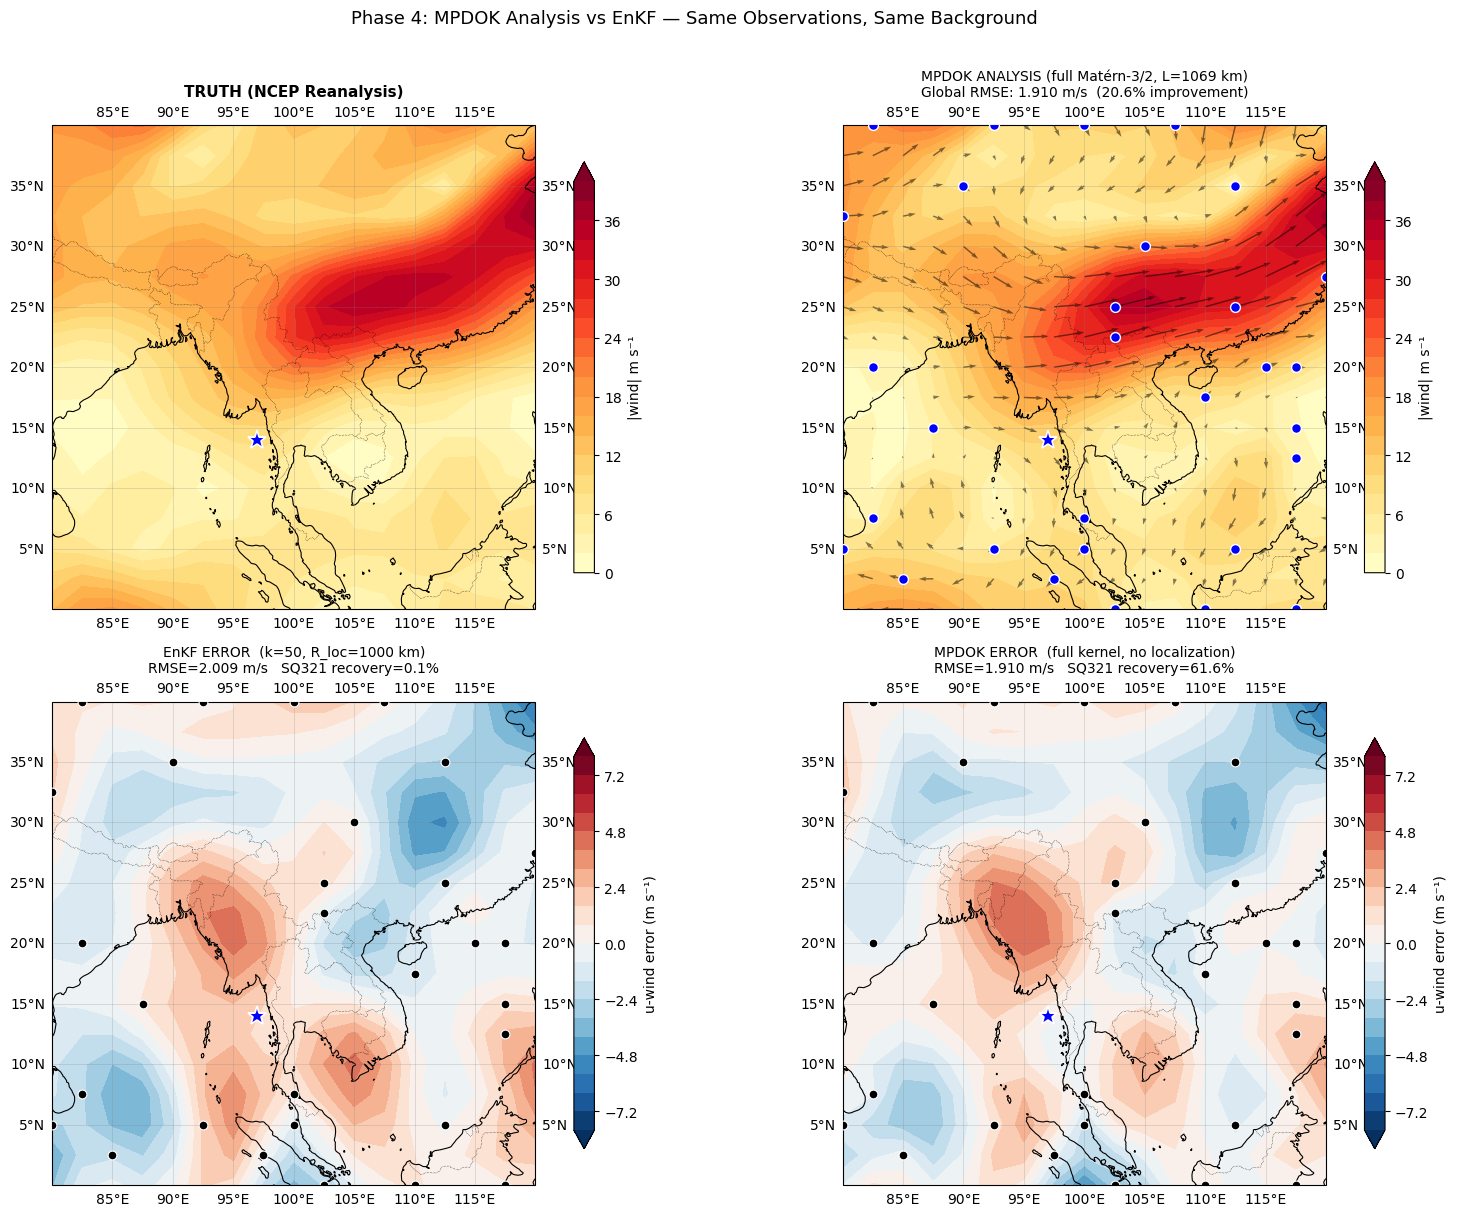

Saved fig09_mpdok_analysis.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                          subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.ravel()
map_kw   = dict(transform=ccrs.PlateCarree())
spd_lvls = np.linspace(0, 40, 21)
err_max  = 8.0
err_lvls = np.linspace(-err_max, err_max, 21)

def add_features(ax):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', alpha=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.4)
    ax.set_extent([80, 120, 0, 40], crs=ccrs.PlateCarree())
    ax.plot(SQ321_LON, SQ321_LAT, '*', ms=14, color='blue',
            markeredgecolor='white', markeredgewidth=1.2, **map_kw, zorder=7)

for ax in axes:
    add_features(ax)

# ── top-left: truth ───────────────────────────────────────────────────────────
cf0 = axes[0].contourf(LON2D, LAT2D, np.sqrt(u250**2+v250**2),
                        levels=spd_lvls, cmap='YlOrRd', extend='max', **map_kw)
plt.colorbar(cf0, ax=axes[0], label='|wind| m s⁻¹', shrink=0.85)
axes[0].set_title('TRUTH (NCEP Reanalysis)', fontsize=11, fontweight='bold')

# ── top-right: MPDOK analysis wind speed ─────────────────────────────────────
cf1 = axes[1].contourf(LON2D, LAT2D, np.sqrt(u_mpdok**2+v_mpdok**2),
                        levels=spd_lvls, cmap='YlOrRd', extend='max', **map_kw)
plt.colorbar(cf1, ax=axes[1], label='|wind| m s⁻¹', shrink=0.85)
axes[1].quiver(LON2D, LAT2D, u_mpdok, v_mpdok, scale=400, width=0.003,
               color='k', alpha=0.5, **map_kw)
axes[1].scatter(obs_lon, obs_lat, s=50, c='blue', edgecolors='white',
                lw=1, **map_kw, zorder=5)
axes[1].set_title(f'MPDOK ANALYSIS (full Matérn-3/2, L={L_matern:.0f} km)\n'
                  f'Global RMSE: {rmse_mpdok:.3f} m/s  ({(1-rmse_mpdok/rmse_bg)*100:.1f}% improvement)',
                  fontsize=10)

# ── bottom-left: EnKF analysis error ─────────────────────────────────────────
err_enkf_2d = (x_enkf[:N_grid] - x_truth[:N_grid]).reshape(nlat, nlon)
cf2 = axes[2].contourf(LON2D, LAT2D, err_enkf_2d,
                        levels=err_lvls, cmap='RdBu_r', extend='both', **map_kw)
plt.colorbar(cf2, ax=axes[2], label='u-wind error (m s⁻¹)', shrink=0.85)
axes[2].scatter(obs_lon, obs_lat, s=40, c='black', edgecolors='white',
                lw=0.8, **map_kw, zorder=5)
axes[2].set_title(f'EnKF ERROR  (k=50, R_loc={R_loc:.0f} km)\n'
                  f'RMSE={rmse_enkf:.3f} m/s   SQ321 recovery={((1-err_enkf_sq/err_bg_sq)*100):.1f}%',
                  fontsize=10)

# ── bottom-right: MPDOK analysis error ────────────────────────────────────────
err_mpdok_2d = (x_mpdok[:N_grid] - x_truth[:N_grid]).reshape(nlat, nlon)
cf3 = axes[3].contourf(LON2D, LAT2D, err_mpdok_2d,
                        levels=err_lvls, cmap='RdBu_r', extend='both', **map_kw)
plt.colorbar(cf3, ax=axes[3], label='u-wind error (m s⁻¹)', shrink=0.85)
axes[3].scatter(obs_lon, obs_lat, s=40, c='black', edgecolors='white',
                lw=0.8, **map_kw, zorder=5)
axes[3].set_title(f'MPDOK ERROR  (full kernel, no localization)\n'
                  f'RMSE={rmse_mpdok:.3f} m/s   SQ321 recovery={recovery_mpdok*100:.1f}%',
                  fontsize=10)

plt.suptitle('Phase 4: MPDOK Analysis vs EnKF — Same Observations, Same Background',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig09_mpdok_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig09_mpdok_analysis.png')

## 4. Kalman Gain Comparison — The Key Visual

The Kalman gain column for the nearest observation to SQ321 shows exactly how much information reaches the turbulence location. The contrast between EnKF (hard zero beyond R_loc) and MPDOK (physically-decaying, nonzero everywhere) is the core of the argument.

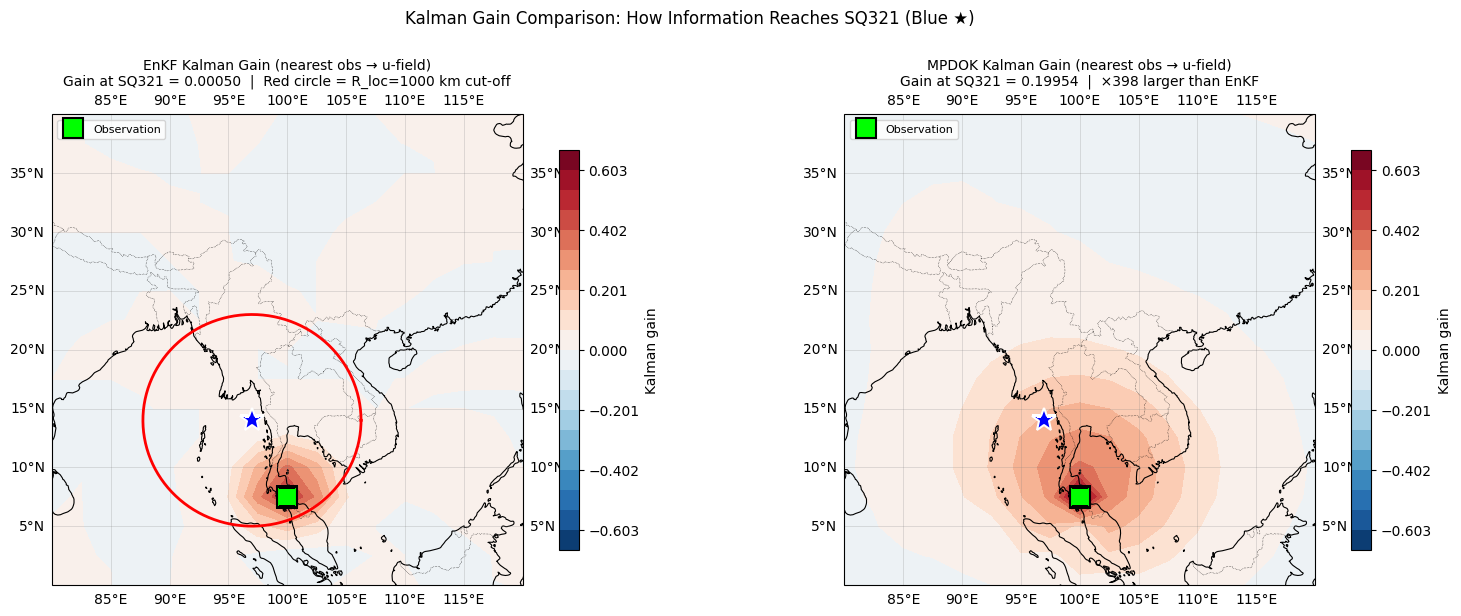

Saved fig10_gain_comparison.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})
map_kw = dict(transform=ccrs.PlateCarree())

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', alpha=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.4)
    ax.set_extent([80, 120, 0, 40], crs=ccrs.PlateCarree())
    ax.plot(SQ321_LON, SQ321_LAT, '*', ms=18, color='blue',
            markeredgecolor='white', markeredgewidth=1.5, **map_kw, zorder=7)
    ax.plot(nearest_obs_lon, nearest_obs_lat, 's', ms=14,
            color='lime', markeredgecolor='k', markeredgewidth=1.5,
            **map_kw, zorder=7, label='Observation')

# shared colour scale
vmax = max(np.abs(gain_2d_enkf).max(), np.abs(gain_2d_mpdok).max())
lvls = np.linspace(-vmax, vmax, 21)

# ── left: EnKF gain ───────────────────────────────────────────────────────────
cf1 = axes[0].contourf(LON2D, LAT2D, gain_2d_enkf,
                        levels=lvls, cmap='RdBu_r', **map_kw)
plt.colorbar(cf1, ax=axes[0], label='Kalman gain', shrink=0.85)
# localization circle
theta = np.linspace(0, 2*np.pi, 360)
dlon_c = R_loc / (6371 * np.cos(np.radians(SQ321_LAT))) * (180/np.pi)
dlat_c = R_loc / 6371 * (180/np.pi)
axes[0].plot(SQ321_LON + dlon_c*np.cos(theta),
             SQ321_LAT + dlat_c*np.sin(theta),
             'r-', lw=2, **map_kw, zorder=5)
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title(f'EnKF Kalman Gain (nearest obs → u-field)\n'
                  f'Gain at SQ321 = {gain_sq321_enkf:.5f}  |  Red circle = R_loc={R_loc:.0f} km cut-off',
                  fontsize=10)

# ── right: MPDOK gain ─────────────────────────────────────────────────────────
cf2 = axes[1].contourf(LON2D, LAT2D, gain_2d_mpdok,
                        levels=lvls, cmap='RdBu_r', **map_kw)
plt.colorbar(cf2, ax=axes[1], label='Kalman gain', shrink=0.85)
axes[1].legend(loc='upper left', fontsize=8)
axes[1].set_title(f'MPDOK Kalman Gain (nearest obs → u-field)\n'
                  f'Gain at SQ321 = {gain_sq321_mpdok:.5f}  |  '
                  f'×{gain_sq321_mpdok/max(gain_sq321_enkf,1e-10):.0f} larger than EnKF',
                  fontsize=10)

plt.suptitle('Kalman Gain Comparison: How Information Reaches SQ321 (Blue ★)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig10_gain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig10_gain_comparison.png')

## 5. Eigenspectrum: Three Covariances Compared

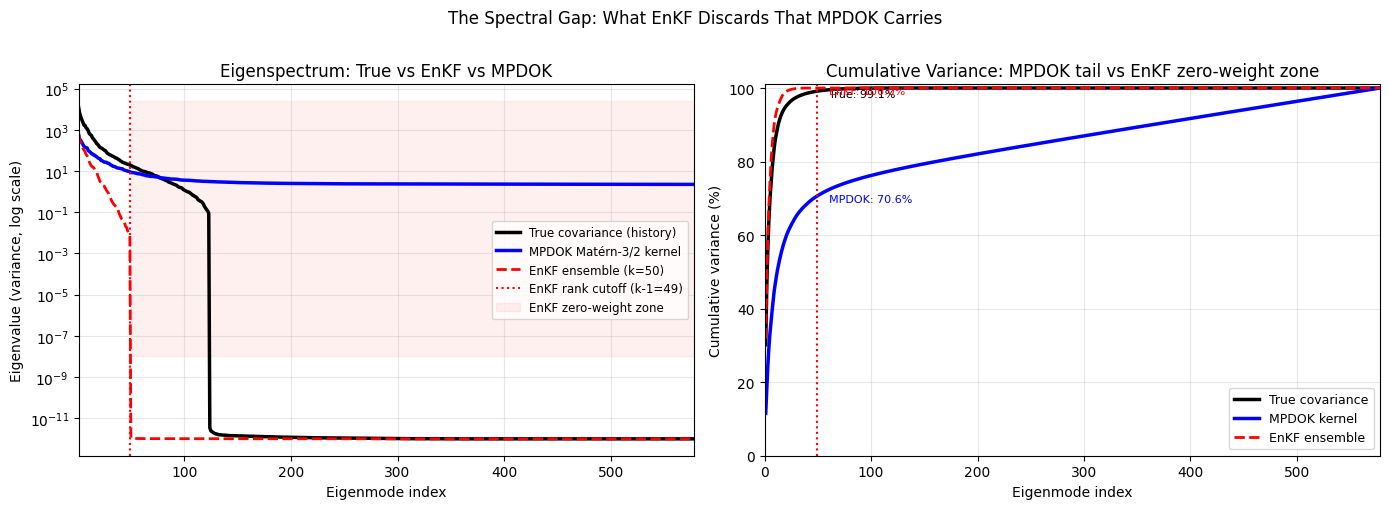

Saved fig11_spectrum_3way.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
modes = np.arange(1, N_state + 1)

# ── left: eigenvalue spectra ──────────────────────────────────────────────────
ax = axes[0]
ax.semilogy(modes, eigs_true  + 1e-12, 'k-',  lw=2.5, label='True covariance (history)')
ax.semilogy(modes, eigs_mpdok + 1e-12, 'b-',  lw=2.5, label='MPDOK Matérn-3/2 kernel')
ax.semilogy(modes, eigs_ens   + 1e-12, 'r--', lw=2.0, label=f'EnKF ensemble (k=50)')
ax.axvline(49, color='red',  lw=1.5, ls=':',  label='EnKF rank cutoff (k-1=49)')
ax.fill_betweenx([1e-8, eigs_true.max()*2],
                 50, N_state, alpha=0.06, color='red',
                 label='EnKF zero-weight zone')
ax.set_xlabel('Eigenmode index')
ax.set_ylabel('Eigenvalue (variance, log scale)')
ax.set_title('Eigenspectrum: True vs EnKF vs MPDOK')
ax.legend(fontsize=8.5)
ax.set_xlim(1, N_state)
ax.grid(alpha=0.3, which='both')

# ── right: cumulative variance ────────────────────────────────────────────────
ax2 = axes[1]
cumvar_true  = np.cumsum(eigs_true)  / eigs_true.sum()
cumvar_mpdok_norm = np.cumsum(eigs_mpdok) / eigs_mpdok.sum()
cumvar_ens   = np.cumsum(eigs_ens)   / (eigs_ens.sum() + 1e-30)

ax2.plot(modes, cumvar_true  * 100, 'k-',  lw=2.5, label='True covariance')
ax2.plot(modes, cumvar_mpdok_norm * 100, 'b-',  lw=2.5, label='MPDOK kernel')
ax2.plot(modes, cumvar_ens   * 100, 'r--', lw=2.0, label='EnKF ensemble')
ax2.axvline(49, color='red', lw=1.5, ls=':')

# annotate the gap at k=49
for label, cv, c in [('True',  cumvar_true,        'k'),
                      ('MPDOK', cumvar_mpdok_norm,  'b'),
                      ('EnKF',  cumvar_ens,          'r')]:
    ax2.annotate(f'{label}: {cv[48]*100:.1f}%', xy=(49, cv[48]*100),
                 fontsize=8, color=c, xytext=(60, cv[48]*100 - 1.5))

ax2.set_xlabel('Eigenmode index')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_title('Cumulative Variance: MPDOK tail vs EnKF zero-weight zone')
ax2.legend(fontsize=9)
ax2.set_xlim(0, N_state)
ax2.set_ylim(0, 101)
ax2.grid(alpha=0.3)

plt.suptitle('The Spectral Gap: What EnKF Discards That MPDOK Carries', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig11_spectrum_3way.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig11_spectrum_3way.png')

## 6. Save MPDOK Outputs

In [7]:
np.savez('phase4_mpdok.npz',
         x_mpdok=x_mpdok,
         P_mpdok=P_mpdok,
         K_mpdok=K_mpdok,
         eigs_mpdok=eigs_mpdok,
         gain_2d_mpdok=gain_2d_mpdok,
         gain_sq321_mpdok=np.float64(gain_sq321_mpdok),
         rmse_mpdok=np.float64(rmse_mpdok),
         err_mpdok_sq=np.float64(err_mpdok_sq),
         err_mpdok_ti=np.float64(err_mpdok_ti),
         recovery_mpdok=np.float64(recovery_mpdok),
         recovery_mpdok_ti=np.float64(recovery_mpdok_ti),
         L_matern=np.float64(L_matern))

print('Saved phase4_mpdok.npz')
print()
print('=== Phase 4 Summary ===')
print(f'Method comparison (same background, same {len(obs_idx)} observations):')
print()
print(f'  {"Metric":<35} {"Background":>12} {"EnKF":>10} {"MPDOK":>10}')
print(f'  {"-"*70}')
print(f'  {"Global RMSE (m/s)":<35} {rmse_bg:>12.3f} {rmse_enkf:>10.3f} {rmse_mpdok:>10.3f}')
print(f'  {"SQ321 u-error (m/s)":<35} {err_bg_sq:>12.3f} {err_enkf_sq:>10.3f} {err_mpdok_sq:>10.3f}')
print(f'  {"SQ321 recovery (%)":<35} {0:>12.1f} {(1-err_enkf_sq/err_bg_sq)*100:>10.1f} {recovery_mpdok*100:>10.1f}')
print(f'  {"High-TI region error (m/s)":<35} {err_bg_ti:>12.3f} {err_enkf_ti:>10.3f} {err_mpdok_ti:>10.3f}')
print(f'  {"SQ321 Kalman gain":<35} {0:>12} {gain_sq321_enkf:>10.5f} {gain_sq321_mpdok:>10.5f}')
print()
print(f'MPDOK Kalman gain at SQ321 is {gain_sq321_mpdok/max(gain_sq321_enkf,1e-10):.0f}× larger than EnKF.')
print(f'This is the direct consequence of the full kernel vs rank-{int(d3["K_ENS"])-1} truncation.')

Saved phase4_mpdok.npz

=== Phase 4 Summary ===
Method comparison (same background, same 30 observations):

  Metric                                Background       EnKF      MPDOK
  ----------------------------------------------------------------------
  Global RMSE (m/s)                          2.404      2.009      1.910
  SQ321 u-error (m/s)                        1.607      1.606      0.617
  SQ321 recovery (%)                           0.0        0.1       61.6
  High-TI region error (m/s)                 4.609      4.595      4.834
  SQ321 Kalman gain                              0    0.00050    0.19954

MPDOK Kalman gain at SQ321 is 398× larger than EnKF.
This is the direct consequence of the full kernel vs rank-49 truncation.
